In [40]:
import sys
sys.path.append("../")

from config import *
from figs_config import *

# II. Empirical maps

## _Colour scheme_

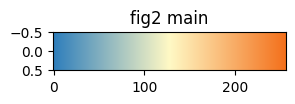

In [41]:
gnrd,_ = three_colours_gradient(lo=plt.cm.Blues(0.7), mid=plt.cm.YlOrBr(0.1), hi=plt.cm.Oranges(0.6), plot=False)
show_colour_scheme(gnrd, "fig2 main")

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Get an existing colormap and sample a segment
lincmap = plt.get_cmap('YlOrBr')
pct_colours = lincmap(np.linspace(0.3, .6, len(test_percentages)))
sns.color_palette(pct_colours)

[(0.996078431372549, 0.8434755863129565, 0.4691580161476355),
 (0.996078431372549, 0.7349019607843138, 0.28),
 (0.9949711649365629, 0.5974778931180315, 0.15949250288350636),
 (0.939607843137255, 0.4713725490196078, 0.09490196078431372)]

In [43]:
corder = ['gene expression', 'MEG', 'structural', 'functional', 'metabolism', 'expansion']
ccolours = [
    to_hex(plt.cm.terrain(0.2)),  # gene: light turquoise
    to_hex(plt.cm.spring(0.65)),  # MEG: orange
    to_hex(plt.cm.cubehelix(0.7)),  # structural: violet
    to_hex(plt.cm.terrain(0.3)),  # functional: green
    to_hex(plt.cm.nipy_spectral(0.3)), # metabolism: blue
    to_hex(plt.cm.spring(0.37)) # expansion: pink
]

cpal = dict(zip(corder, ccolours))
sns.color_palette(ccolours)

[(0.0, 0.6980392156862745, 0.6980392156862745),
 (1.0, 0.6509803921568628, 0.34901960784313724),
 (0.8117647058823529, 0.615686274509804, 0.8588235294117647),
 (0.19215686274509805, 0.8392156862745098, 0.4392156862745098),
 (0.0, 0.596078431372549, 0.8666666666666667),
 (1.0, 0.3686274509803922, 0.6313725490196078)]

## _Data specs_

In [44]:
import joblib
src_pvdata = joblib.load( projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')

In [45]:
import pandas as pd
maptags = pd.read_table(projdir + '/data/surf_map_names', delimiter = " ", dtype = str)
maptags = list(maptags.columns)

In [46]:
space = 'fsLR-4k'
geometry = 'reduced-midthickness'
datasource = 'neuromaps'
strategy = 'dsk33'
niters = 100

## Full maps and sampling exmaple

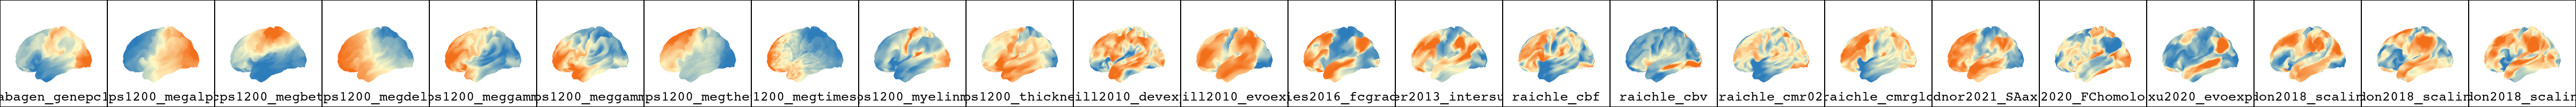

In [8]:
import pyvista as pv

pl = pv.Plotter(shape = (1, len(maptags)), window_size = (4800, 200))

for mi, maptag in enumerate(maptags):
    pl.subplot(0,mi)
    pl.add_mesh(src_pvdata.rotate_z(180), scalars=maptag, cmap = gnrd, \
                clim = (np.percentile(src_pvdata[maptag], 5), np.percentile(src_pvdata[maptag], 95)), \
                **mesh_aes)
    pl.add_text(maptag, font_size = 10, font='courier', position = 'lower_edge')
    pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/neuromaps_instances.svg')

In [67]:
other_maps = list(global_i_s.index)

CMAT = np.ones((len(other_maps), len(other_maps)))

for i, curr_map in enumerate(other_maps):
    for j, other_map in enumerate(other_maps):

        CMAT[i,j] = np.ma.corrcoef(np.ma.masked_invalid(src_pvdata[curr_map]), \
                        np.ma.masked_invalid(src_pvdata[other_map]))[1,0]

In [68]:
other_maps

['abagen_genepc1',
 'hcps1200_megbeta',
 'hcps1200_meggamma2',
 'hcps1200_meggamma1',
 'hcps1200_megtimescale',
 'hcps1200_megtheta',
 'hcps1200_megalpha',
 'hcps1200_megdelta',
 'hcps1200_thickness',
 'hcps1200_myelinmap',
 'xu2020_FChomology',
 'mueller2013_intersubjvar',
 'margulies2016_fcgradient01',
 'sydnor2021_SAaxis',
 'raichle_cbv',
 'raichle_cbf',
 'raichle_cmrglc',
 'raichle_cmr02',
 'reardon2018_scalinghcp',
 'xu2020_evoexp',
 'hill2010_devexp',
 'reardon2018_scalingnih',
 'reardon2018_scalingpnc',
 'hill2010_evoexp']

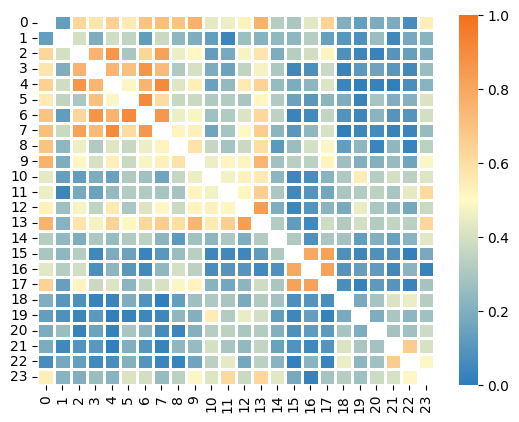

In [69]:
import copy
import matplotlib.pyplot as plt
import seaborn as sns

corr_nan = CMAT.copy()
np.fill_diagonal(corr_nan, np.nan)

sns.heatmap(abs(corr_nan), cmap = gnrd, linewidth = 1, linecolor = 'w', vmin = 0, vmax = 1)
plt.savefig(projdir + '/figs/main/supplements_neuromaps_corrmat.svg')

<Axes: >

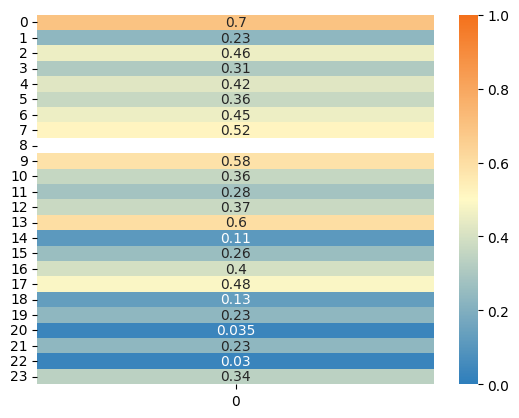

In [70]:
sns.heatmap( abs(corr_nan)[other_maps.index('hcps1200_thickness'),:].reshape(-1,1), vmin = 0, vmax = 1, annot=True, cmap = gnrd )

In [71]:
trg_corrs = abs(corr_nan)[other_maps.index('hcps1200_thickness'),:]

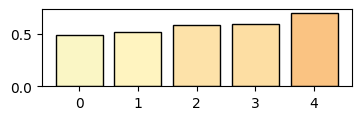

In [72]:
import matplotlib.pyplot as plt

values = trg_corrs[ trg_corrs.argsort() ][-6:-1]

colors = [ gnrd(value) for value in values ]

plt.figure(figsize = (4,1))
plt.bar(x=np.arange(5), height=values, color=colors, edgecolor = 'k')
plt.ylim = ([0.4, 1])

plt.savefig(projdir + '/figs/main/supplements_example_covariates_barplot.svg')

In [60]:
values

array([0.48490684, 0.51883381, 0.58260955, 0.59771156, 0.69899677])

* DSK33-first sampling

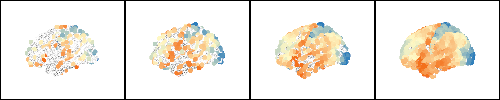

In [18]:
import pyvista as pv

pl = pv.Plotter(shape = (1, len(test_percentages)), window_size = (500,100))

for pi, percentage in enumerate(test_percentages):

    sampling = joblib.load( projdir + f'/data/sampling/{space}_{geometry}_samp-{strategy}_pct-{str(percentage)}_iters-100.pkl')
    known_coords, known_verts, unknown_coords, unknown_verts = sampling[1]
    pl.subplot(0, pi)
    pl.add_mesh(src_pvdata.rotate_z(180), show_edges=True, edge_color = 'w', color = 'k', **mesh_aes)
    pl.add_points(pv.PolyData(known_coords[:,:,0]).rotate_z(180), clim = (np.percentile(src_pvdata['hcps1200_thickness'], 5), np.percentile(src_pvdata['hcps1200_thickness'], 95)), \
                  scalars = src_pvdata['hcps1200_thickness'][known_verts[:,0].flatten().astype(int)],\
                  cmap = gnrd, \
                  point_size = 5, show_scalar_bar=False, **point_aes)
    pl.camera_position = 'yz'
    
pl.show(jupyter_backend = 'static')
#pl.save_graphic(projdir + '/figs/main/fslr4k_dsk33_samples_different_percentages.svg')

## Voronoi Standard Error

In [20]:
import matplotlib.pyplot as plt
from scipy.stats import zscore

all_standardized_voronoi_se = []

voronoi_se = np.zeros((niters, len(test_percentages)))
voronoi_se_zscored = np.zeros((niters, len(test_percentages)))

for pi, p in enumerate(test_percentages):
    labels, results = joblib.load(projdir + \
        f'/results/{datasource}/{strategy}/{space}_{maptags[0]}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')
    
    for i in range(niters):
        voronoi_se[i, pi] = results[0][i][2]

    voronoi_se_zscored[:,pi] = zscore( voronoi_se[:,pi] )

all_standardized_voronoi_se.append(voronoi_se_zscored)

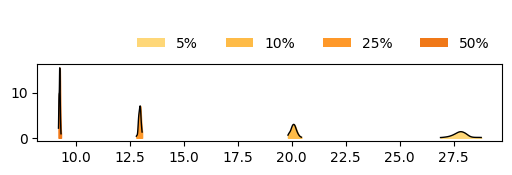

In [21]:
import matplotlib.pyplot as plt
from scipy.stats import zscore, gaussian_kde

plt.figure(figsize = (6,1))
bins = np.histogram_bin_edges(voronoi_se.T, bins=25)

for pi, p in enumerate(test_percentages):

    data = voronoi_se[:,pi]
    #plt.hist(data, bins = bins, color = pct_colours[pi], edgecolor = 'w', density=True, alpha = 1)
    #plt.axvline(np.mean(voronoi_se[:,pi]), linewidth = 1, color = 'k', alpha = .5)
    x = np.linspace(data.min(), data.max(), 50)
    kde = gaussian_kde(data)
    plt.plot(x, kde(x), color = 'k', linewidth=1)

    x = np.linspace(data.min(), data.max(), 50)
    y = gaussian_kde(data)(x)
    
    plt.fill_between(x, y, 0, color = pct_colours[pi], alpha=1)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=pct_colours[pi], label=str(p) + "%")
    for pi, p in enumerate(test_percentages)
]

plt.legend(handles=legend_elements, title=" ", loc='lower right',
bbox_to_anchor=(1, 1.02), frameon=False, ncol = len(test_percentages))
plt.show()

In [22]:
for pi in range(len(test_percentages)):
    print("Sparse sample at: " + str(test_percentages[pi]) + "%")
    print('             mean VSE: ' + str(voronoi_se[:,pi].mean()) )
    print('             variance VSE: ' + str(voronoi_se[:,pi].std()) )

Sparse sample at: 5%
             mean VSE: 27.801388584418696
             variance VSE: 0.3175455716724613
Sparse sample at: 10%
             mean VSE: 20.093168342281658
             variance VSE: 0.12780017136936897
Sparse sample at: 25%
             mean VSE: 12.970009534698617
             variance VSE: 0.05287271941957281
Sparse sample at: 50%
             mean VSE: 9.259219011493085
             variance VSE: 0.02470086034221325


## Supplements: Moran scatterplots

In [23]:
from interpmodules import helpers

global_i_s = pd.DataFrame(index = maptags, columns = ['i'])

Dist = helpers.internal_distance_matrix(src_pvdata.points, 'euclidean')

for maptag in maptags:
    global_i = helpers.morans_i(Dist, src_pvdata[maptag], normalize=True)
    global_i_s.loc[maptag] = global_i

In [24]:
from scipy.sparse import coo_matrix

dist = 1 / Dist
np.fill_diagonal(dist, 0)
dist /= dist.sum(axis=-1, keepdims=True)
spdist = coo_matrix(dist)

In [25]:
def moran_permutation_test(x, W, n_perm=9999, alternative="two-sided", seed=0):
    rng = np.random.default_rng(seed)

    I_obs = helpers.morans_i(W, x, normalize=True, local=False, invert_dist=True)
    z = x - np.mean(x)

    # precompute denom for speed; permuting z doesn't change denom
    denom = np.dot(z, z)
    if denom == 0:
        return I_obs, np.nan, None

    Iz = np.empty(n_perm, dtype=float)
    for b in range(n_perm):
        zp = rng.permutation(z)
        Iz[b] = np.dot(zp, W @ zp) / denom

    # p-value with +1 correction (recommended)
    if alternative == "greater":      # positive autocorrelation
        p = (np.sum(Iz >= I_obs) + 1) / (n_perm + 1)
    elif alternative == "less":       # negative autocorrelation
        p = (np.sum(Iz <= I_obs) + 1) / (n_perm + 1)
    elif alternative == "two-sided":
        p = (np.sum(np.abs(Iz) >= abs(I_obs)) + 1) / (n_perm + 1)
    else:
        raise ValueError("alternative must be 'greater', 'less', or 'two-sided'")

    return I_obs, p, Iz

In [26]:
pperm = np.zeros(len(maptags))
for mi, maptag in enumerate(maptags):
    pperm[mi] = moran_permutation_test(src_pvdata[maptag], dist, n_perm=1000)[1]
pperm

array([0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999])

In [29]:
# Manually assign category labels

# arrange the data frame - this is hard coded
category = ['gene expression'] + ['MEG'] * 7 + ['structural'] * 2 +\
['expansion']*2 + ['functional']*2 + ['metabolism']*4 + ['functional']*2 + ['expansion']*4
global_i_s['category'] = category

global_i_s = global_i_s.sort_values(by=['category', 'i'], ascending = True)
global_i_s.category = global_i_s.category.astype('category')
global_i_s.category = global_i_s.category.cat.set_categories(corder)
global_i_s = global_i_s.sort_values(["category", "i"])


In [30]:
global_i_s

,i,category
abagen_genepc1,0.258006,gene expression
hcps1200_megbeta,0.265799,MEG
hcps1200_meggamma2,0.267007,MEG
hcps1200_meggamma1,0.288112,MEG
hcps1200_megtimescale,0.296607,MEG
hcps1200_megtheta,0.299977,MEG
hcps1200_megalpha,0.33919,MEG
hcps1200_megdelta,0.339774,MEG
hcps1200_thickness,0.159796,structural
hcps1200_myelinmap,0.161553,structural


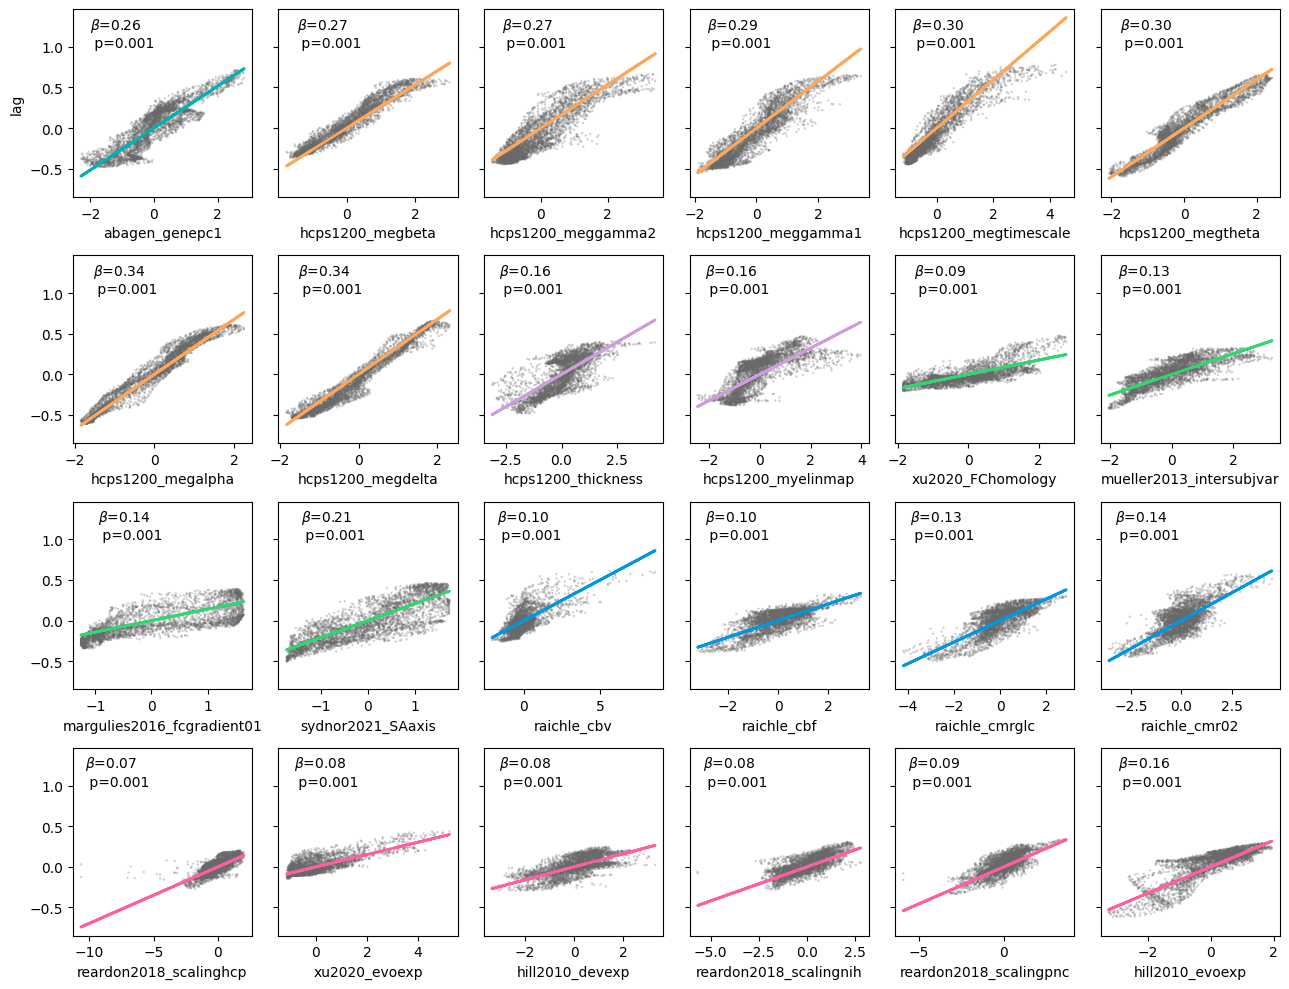

In [31]:
from scipy.stats import zscore

fig, axs = plt.subplots(4, 6, figsize = (13, 10), sharey=True)

moran_scatter = pd.DataFrame()

for mi, maptag in enumerate(global_i_s.index):


    row, col = mi // 6, mi % 6
    
    zX = zscore(src_pvdata[maptag])
    #splag = np.average(np.repeat(zX[np.newaxis], src_pvdata.n_points, axis=0), weights=spdist, axis=1)
    splag = spdist @ zX
    normalized_og = zscore(src_pvdata[maptag])
    axs[row, col].scatter(x = zX, y =splag, s=3, c='dimgray', edgecolor = 'none', alpha = .3, rasterized = True)
    axs[row, col].set_xlabel(maptag)
    axs[0,0].set_ylabel("lag")

    #axs[mi].axhline(0, color="k", lw=1)
    #axs[mi].axvline(0, color="k", lw=1)
    
    # regression line
    m = (zX @ splag) / (zX @ zX)   # Moran's I
    moran_scatter.at[maptag,0] = m
    axs[row,col].plot(zX, m * zX, linewidth = 2, color=cpal[global_i_s.at[maptag, 'category']])
    axs[row,col].text(x=zX.min() + 0.3, y=1, s=r"$\beta$=" + "%.2f" % m + "\n p=0.001")
plt.tight_layout()

plt.savefig(projdir + '/figs/main/neuromaps_moran_scatterplots.svg')

In [32]:
joblib.dump(global_i_s, projdir + '/results/stats/neuromaps_full_global_i_s.pkl')

['/home/yzhou/gitrepo/interpolate//results/stats/neuromaps_full_global_i_s.pkl']

In [62]:
global_i_s = joblib.load(projdir + '/results/stats/neuromaps_fullmap_globalstats.pkl')

## Sample Global Moran's I

In [75]:
# Compute global Moran's I for the samples

sample_global_i_s = np.zeros((len(test_percentages), len(maptags), niters))

for pi, percentage in enumerate(test_percentages):

    sampling = joblib.load( projdir + f'/data/sampling/{space}_{geometry}_samp-{strategy}_pct-{str(percentage)}_iters-100.pkl')
    known_coords, known_verts, unknown_coords, unknown_verts = sampling[1]

    for mi, maptag in enumerate(maptags):
        for j in range(niters):
            dj = helpers.internal_distance_matrix(known_coords[:,:,j])
            xj = src_pvdata[maptag][known_verts[:,j].flatten().astype(int)]
    
            sample_global_i_s[pi, mi, j] = helpers.morans_i(dj, xj, normalize=True) # Need to row-normalize the distance matrix
# it took a while so i'm saving it

In [76]:
np.save(projdir + '/results/neuromaps_samples_global_i_s.npy', sample_global_i_s)

In [77]:
sample_global_i_s.shape

(4, 24, 100)

In [78]:
samples_i_s = pd.DataFrame(sample_global_i_s.mean(axis=0).T, columns=[maptags], index=np.arange(100))

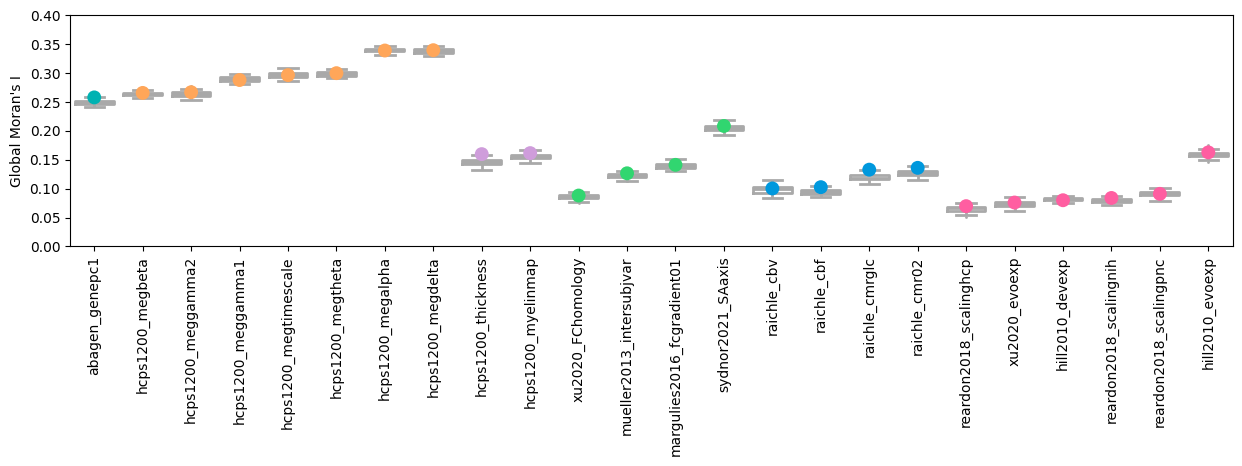

In [82]:
import seaborn as sns

plt.figure(figsize = (15,3))

sns.scatterplot(global_i_s, x=morder, y='i', \
                hue = 'category', hue_order = corder, \
                palette = cpal, edgecolor = 'none',  s = 100, legend = False, zorder = 10
)

sns.boxplot( samples_i_s, hue_order = morder, color='darkgray', fliersize=1, linewidth = 2, fill=False)


plt.ylim([0,.4])
plt.xticks(rotation=90)
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("Global Moran's I")
plt.savefig(projdir + '/figs/main/neuromaps_surf_maps_moran_i_normalized.svg')

## Variography

### Supplements: full map variograms PCs

* same bin edges for all the maps

In [34]:
from interpmodules import helpers

Dist = helpers.internal_distance_matrix(src_pvdata.points)

In [36]:
nh = 25

max_lag = Dist.max()
bin_edges = np.linspace(0.000001, max_lag, nh + 1)

In [52]:
# rearrange map list order

morder = list(global_i_s.index)

In [71]:
import joblib
from scipy.stats import zscore

# h should be the same
nh = 25
all_ev = np.zeros((nh, len(morder)))


for mi, maptag in enumerate(morder):

    h, ev, _ = helpers.get_empirical_variogram_fast(x=zscore(src_pvdata[maptag]), X=src_pvdata.points, h_bounds = bin_edges, D=Dist,nh=nh)
    all_ev[:,mi] = ev

joblib.dump( (morder, h, all_ev), projdir + '/results/stats/neuromaps_collected_expvgm.pkl')

['/home/yzhou/gitrepo/interpolate//results/stats/neuromaps_collected_expvgm.pkl']

In [10]:
morder, h, all_ev = joblib.load( projdir + '/results/stats/neuromaps_collected_expvgm.pkl' )

In [11]:
# make a data grid with map-normalized variograms
from skfda.representation.grid import FDataGrid
from scipy.stats import zscore

all_ev_z = zscore(all_ev, axis = 0)
datag = FDataGrid(all_ev_z)

In [12]:
import skfda

fpca = skfda.preprocessing.dim_reduction.FPCA(n_components=3,)

In [13]:
fpca.fit(X=datag)

FPCA(_weights=array([0.01449275, 0.05797101, 0.02898551, 0.05797101, 0.02898551,
       0.05797101, 0.02898551, 0.05797101, 0.02898551, 0.05797101,
       0.02898551, 0.05797101, 0.02898551, 0.05797101, 0.02898551,
       0.05797101, 0.02898551, 0.05797101, 0.02898551, 0.05797101,
       0.02898551, 0.05434783, 0.04347826, 0.01811594]),
     n_components=3)

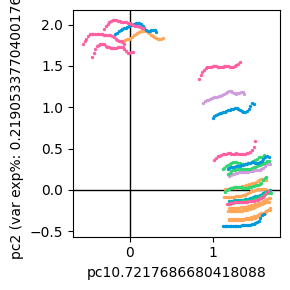

In [18]:
import matplotlib.pyplot as plt

plt.subplots(figsize = (3,3))

xs = np.array(fpca.components_[0].data_matrix).flatten()
ys = np.array(fpca.components_[1].data_matrix).flatten()

plt.axhline(0, color ='k', linewidth =1)
plt.axvline(0, color = 'k', linewidth=1)

for x, y, mi in zip(xs, ys, morder):

    #print(global_i_s.at[mi, "category"])
    
    plt.scatter(
        x + h*0.003,
        y + all_ev_z[:,morder.index(mi)]*0.04,
        color=cpal[global_i_s.at[mi, "category"]],
        alpha=1, s = 2, zorder = 10
    )

plt.scatter(xs, ys, s=0, zorder=10)

plt.xlabel('pc1' + str(fpca.explained_variance_[0]))
plt.ylabel('pc2 (var exp%: ' + str(fpca.explained_variance_[1]))
plt.tight_layout()

plt.savefig(projdir + '/figs/main/neuromaps_map_variogram_functional-pca_sill_normalized.svg')
#plt.show()

In [19]:
print("variance explained: ")
print( fpca.explained_variance_ )

variance explained: 
[0.72176867 0.21905338 0.0544633 ]


* get PCs

In [78]:
pcs = fpca.fit_transform(datag)

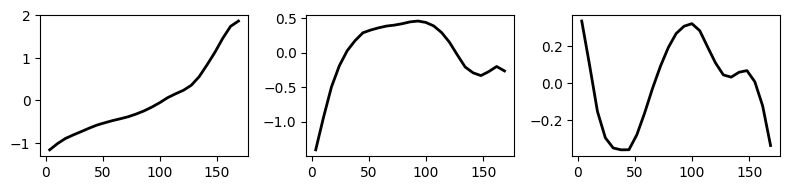

In [79]:
fig, axs = plt.subplots(1,3, figsize = (8, 2))

for c in range(fpca.n_components):
    axs[c].plot(h, pcs[:,c], color = 'k', linewidth=2)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_variograms_fullmaps_fpca_components_sill-normalized.svg')

### Full map experimental variograms

In [81]:
all_ev.shape

(25, 24)

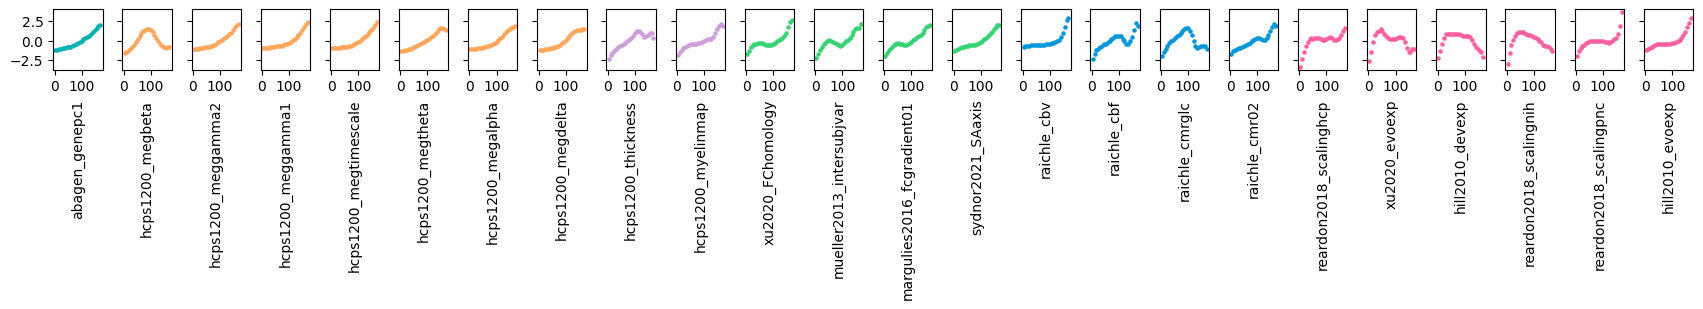

In [20]:
fig, axs = plt.subplots(1, len(morder), figsize = (17,3.25), sharex=True, sharey=True)

for mi, maptag in enumerate(morder):
    axs[mi].scatter( x=h, y=zscore(all_ev[:,mi]), color=cpal[global_i_s.at[maptag, 'category']], s=5 )
    #axs[mi].plot( all_ev[mi], zscore(full_emp_ev_s[mi]), c='k', linewidth = 2, alpha = 0.5 )
    axs[mi].set_xlabel(maptag, rotation = 90)
plt.tight_layout()
#plt.show()

plt.savefig( projdir + '/figs/main/neuromaps_vgm_squiggles_sill-normalized.svg')

### Fit full map to exponential model

* The experimental variograms are sill-standardized (computed on zscored maps)

In [112]:
full_fitted = dict()
full_sills = dict()

In [113]:
# fit each sill-standardized experimental variogram to a gaussian variogram
from scipy.optimize import curve_fit
from interpmodules import helpers

model = helpers.exponential

bin_centers = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
x_long=np.array(bin_centers)
u=bin_centers
nparams = 3

for mi, maptag in enumerate(morder):
    
    ev = all_ev[:,mi]
    
    bounds = ([0.00001]*nparams, [np.nanmax(u), np.nanmax(ev), np.nanmax(ev)/nh])
    cof, cov = curve_fit(model, u, ev, method = 'trf', p0=bounds[1], bounds = bounds, maxfev=1000)
    v_pred = model(x_long, *cof)
    full_fitted[maptag] = v_pred
    full_sills[maptag] = cof[1] + cof[2]

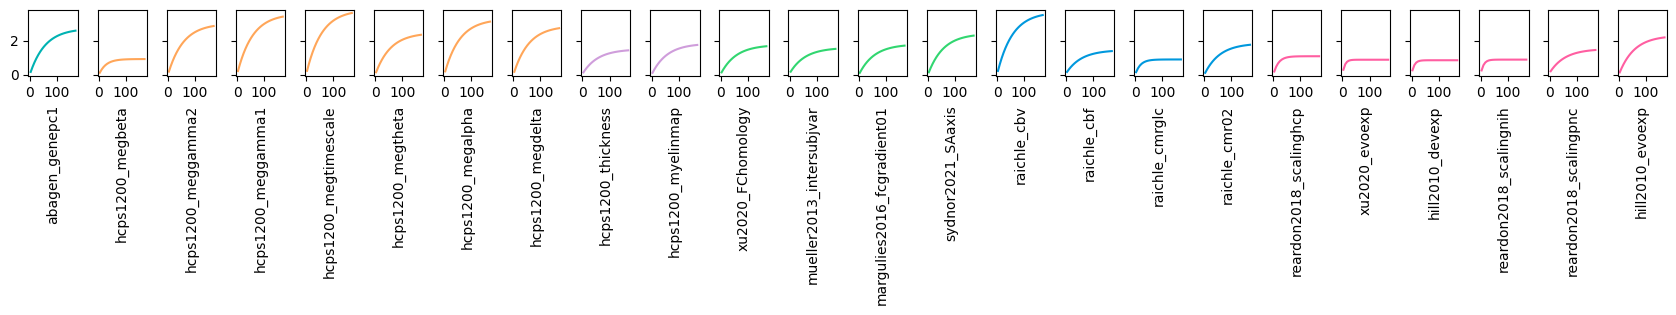

In [108]:
fig, axs = plt.subplots(1, len(morder), figsize = (17,3.25), sharex=True, sharey=True)

for mi, maptag in enumerate(morder):
    axs[mi].plot(h, full_fitted[maptag], color=cpal[global_i_s.at[maptag, 'category']])
    #axs[mi].plot( all_ev[mi], zscore(full_emp_ev_s[mi]), c='k', linewidth = 2, alpha = 0.5 )
    axs[mi].set_xlabel(maptag, rotation = 90)
plt.tight_layout()
#plt.show()

#plt.savefig( projdir + '/figs/main/neuromaps_vgm_squiggles_sill-normalized.svg')
# Don't think I need this figure in the paper

* compute MAE at the full map level

In [114]:
from interpmodules import metrics

mae_full = np.zeros(len(morder))

for mi, maptag in enumerate(morder):
    mae_full[mi] = np.mean( metrics.metric( full_fitted[maptag], all_ev[:,mi], 'residual') ) / full_sills[maptag]

In [153]:
global_i_s['mae-sillnorm'] = mae_full

# Here I save the global metrics for the full empirical maps

* MAE (sill-normalized)
* Global Moran's I
* PC1 and PC2 scores

In [157]:
global_i_s['pc1_scores'] = np.array(fpca.components_[0].data_matrix).flatten()
global_i_s['pc2_scores'] = np.array(fpca.components_[1].data_matrix).flatten()

### Full map variogram fit vs PC

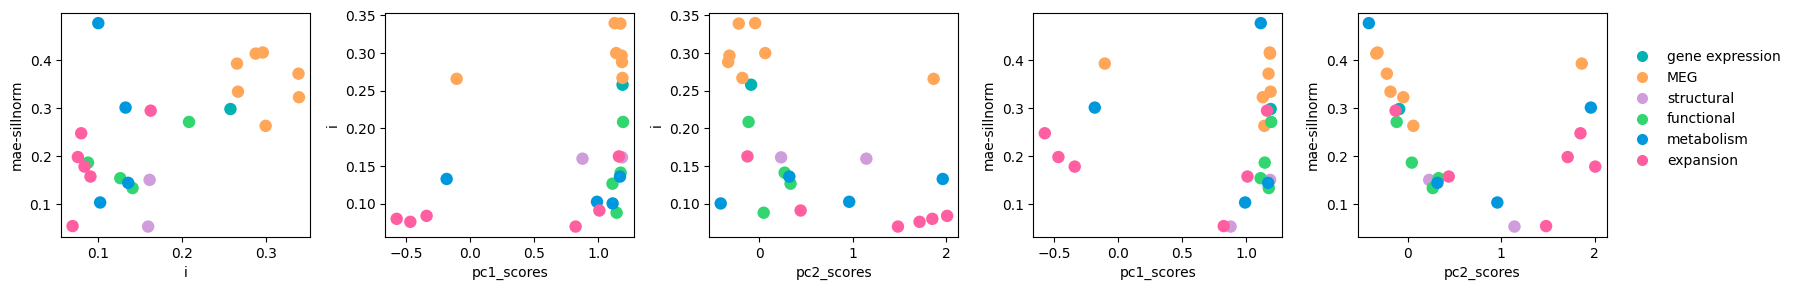

In [162]:
# add regression lines here

fig, axs = plt.subplots(1,5, figsize = (18,3))

sns.scatterplot( global_i_s, x='i', y='mae-sillnorm', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[0])

for i, measure in enumerate(['pc1_scores', 'pc2_scores']):
    
    sns.scatterplot( global_i_s, x=measure, y='i', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[i + 1])
    
sns.scatterplot( global_i_s, x='pc1_scores', y='mae-sillnorm', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[3])

sns.scatterplot( global_i_s, x='pc2_scores', y='mae-sillnorm', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[4])

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="k", linewidth =0, \
           markeredgecolor = 'none',\
           markerfacecolor=to_rgba(ccolours[ci]), markersize=8, \
           label=cat)
    for ci, cat in enumerate(corder)
]

plt.legend(handles=legend_elements, \
           loc='lower right', \
           frameon=False, \
           ncol = 1,\
            bbox_to_anchor=(1.75, 0.25),  # outside right
            borderaxespad=0.5)

plt.tight_layout()
#plt.show()
plt.savefig(projdir + '/figs/main/neuromaps_fullmap_i_vs_mae_scatter_sill-normalized.svg')

In [163]:
joblib.dump(global_i_s, projdir + '/results/stats/neuromaps_fullmap_globalstats.pkl')

['/home/yzhou/gitrepo/interpolate//results/stats/neuromaps_fullmap_globalstats.pkl']

### Sample maps experimental variograms

we only concern ourselves with the fitting of the variogram because there is no "theoretical" model to compare with,
every MAE is calculated between the experimental variogram and an exponential model.

In [57]:
variogram_gof = []
variogram_percentages = []
variogram_maptags = []

In [58]:
from interpmodules import helpers, metrics
import skgstat as skg
from scipy.stats import zscore

Dist = helpers.internal_distance_matrix(src_pvdata.points, 'euclidean')

for mi, maptag in enumerate(maptags):
    for pi, percentage in enumerate(test_percentages):    
        tags, results = joblib.load( projdir + f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')

        for i in range(niters):
            x, y, N, eff_range, psill, nugg = results[1][i]
    
            fit = [ helpers.exponential(h=xi, r=eff_range, c0=psill, nugget=nugg) for xi in x ]
        
            joined = np.concat([fit, y])
            #rescaled = ( joined - joined.min() ) / ( joined.max() - joined.min() )
            #rescaled_fit = rescaled[:len(x)]
            #rescaled_emp = rescaled[len(x):]
            #variogram_gof.append( np.mean(metrics.metric(rescaled_fit, rescaled_emp, 'residual')) )

            # sill normalize
            variogram_gof.append( np.mean(metrics.metric(fit, y, 'residual')) / (psill + nugg) )
            
            variogram_percentages.append( percentage )
            variogram_maptags.append( maptag )

In [59]:
import pandas as pd
variogram_gof_plotdata = pd.DataFrame()
variogram_gof_plotdata['mae'] = variogram_gof
variogram_gof_plotdata['percentage'] = variogram_percentages
variogram_gof_plotdata['maptag'] = variogram_maptags

In [60]:
variogram_gof_plotdata.at[0, 'maptag']

'abagen_genepc1'

In [61]:
variogram_gof_plotdata['category']  = np.zeros(len(variogram_gof_plotdata))

for row in range(len(variogram_gof_plotdata)):

    mapname = variogram_gof_plotdata.at[row, "maptag"]
    variogram_gof_plotdata.at[row,'category'] = global_i_s.at[mapname, "category"]

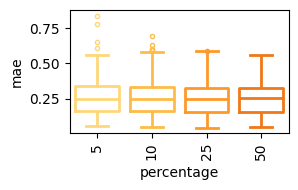

In [62]:
import seaborn as sns

plt.figure(figsize = (3,2))
sns.boxplot(variogram_gof_plotdata, x='percentage', y='mae', hue='percentage', \
            fliersize = 3, linewidth=2, palette = pct_colours, fill = False, linecolor = 'k', legend=False)
plt.xticks(rotation = 90)

plt.tight_layout()

#plt.savefig(projdir + "/figs/main/neuromaps_dsk33_variogram_fit_percentages.svg")

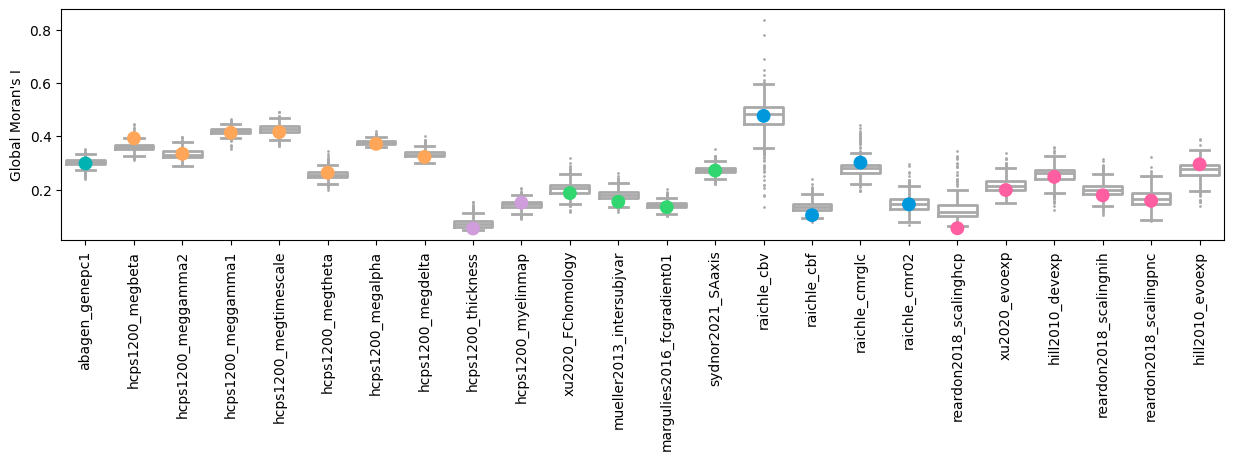

In [63]:
import seaborn as sns

plt.figure(figsize = (15,3))

sns.scatterplot(global_i_s, x=morder, y='mae-sillnorm', \
                hue = 'category', hue_order = corder, \
                palette = cpal, edgecolor = 'none',  s = 100, legend = False, zorder = 10
)

sns.boxplot( variogram_gof_plotdata, x='maptag', y='mae', order=morder, color='darkgray', fliersize=1, linewidth = 2, fill=False)


plt.xticks(rotation=90)
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("Global Moran's I")
plt.savefig(projdir + '/figs/main/neuromaps_surf_maps_mae_sill-normalized.svg')

## Sample maps variograms PCs

* import the results from the interpolation runs

In [64]:
from interpmodules import helpers, metrics
import skgstat as skg

variogram_percentages = []
variogram_maptags = []
variograms = []

Dist = helpers.internal_distance_matrix(src_pvdata.points, 'euclidean')

for mi, maptag in enumerate(maptags):
    for pi, percentage in enumerate(test_percentages):
    
        tags, results = joblib.load( projdir + f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')

        for i in range(niters):
            x, y, N, eff_range, psill, nugg = results[tags.index('variogram')][i]
            h = x
            variograms.append(y)
            variogram_maptags.append(maptag)
            variogram_percentages.append(percentage)
            

In [65]:
import numpy as np

expvgm = np.vstack(variograms)

In [66]:
from skfda.representation.grid import FDataGrid
from scipy.stats import zscore

all_ev_z = zscore(expvgm.T, axis = 0)
datag = FDataGrid(all_ev_z)

In [44]:
import skfda

fpca = skfda.preprocessing.dim_reduction.FPCA(n_components=5)

In [45]:
fpca.fit(datag)

FPCA(_weights=array([3.47258395e-05, 1.38903358e-04, 6.94516790e-05, ...,
       1.30221898e-04, 1.04177518e-04, 4.34072994e-05], shape=(9600,)),
     n_components=5)

In [46]:
colour_categories = []

for vi, v in enumerate(variogram_maptags):
    colour_categories.append( cpal[ global_i_s.at[v, "category"] ] )

In [47]:
pct_colours_points = []

for pi, p in enumerate(variogram_percentages):
    pct_colours_points.append( pct_colours[ test_percentages.index(p) ] )

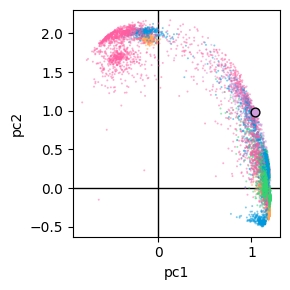

In [97]:
import matplotlib.pyplot as plt
plt.subplots(figsize = (3,3))

xs = np.array(fpca.components_[0].data_matrix).flatten()
ys = np.array(fpca.components_[1].data_matrix).flatten()

plt.axhline(0, color ='k', linewidth =1)
plt.axvline(0, color = 'k', linewidth=1)

plt.scatter(xs, ys, s=2, c=colour_categories, edgecolor = 'none', alpha = .5, zorder=5, rasterized=True)
plt.scatter(xs[3741], ys[3741], s=40, c=colour_categories[3741], edgecolor = 'k', zorder=10)


plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_variograms_dsk33_samples_fpca_embedding.svg')

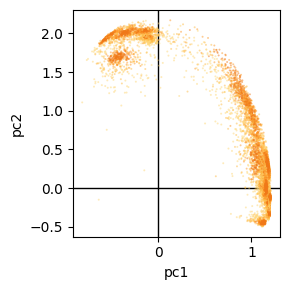

In [49]:
import matplotlib.pyplot as plt


plt.subplots(figsize = (3,3))

xs = np.array(fpca.components_[0].data_matrix).flatten()
ys = np.array(fpca.components_[1].data_matrix).flatten()

plt.axhline(0, color ='k', linewidth =1)
plt.axvline(0, color = 'k', linewidth=1)

plt.scatter(xs, ys, s=2, c=pct_colours_points, edgecolor = 'none', alpha = .5, zorder=10)

plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_variograms_dsk33_samples_fpca_embedding_percentages.svg')

In [50]:
fpca.explained_variance_

array([0.71373983, 0.20758774, 0.0528024 , 0.0367961 , 0.01356511])

In [51]:
pcs = fpca.fit_transform(datag)

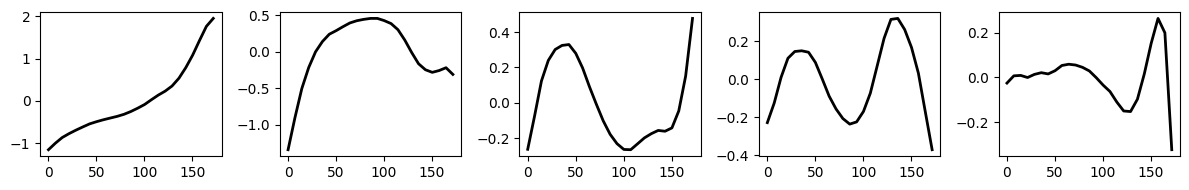

In [52]:
fig, axs = plt.subplots(1,5, figsize = (12, 2))

for c in range(fpca.n_components):
    axs[c].plot(h, pcs[:,c], color = 'k', linewidth=2)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_variograms_dsk33_samples_fpca_components.svg')

In [53]:
pc_scores = pd.DataFrame({"maptag": variogram_maptags, \
                          "percentage": variogram_percentages, \
                           "pc1_scores": np.array(fpca.components_[0].data_matrix).flatten(), \
                           "pc2_scores": np.array(fpca.components_[1].data_matrix).flatten()})

In [67]:
df1 = pc_scores
df2 = variogram_gof_plotdata
common_cols = df1.columns.intersection(df2.columns)

In [68]:
common_cols

Index(['maptag', 'percentage'], dtype='object')

In [69]:
print(df1.duplicated(subset=common_cols).any())
print(df2.duplicated(subset=common_cols).any())

True
True


In [70]:
samp_stats = pd.concat([variogram_gof_plotdata, pc_scores[["pc1_scores", "pc2_scores"]]], axis = 1)

In [71]:
samp_stats = samp_stats[['maptag', 'category', 'percentage', 'mae', 'pc1_scores', 'pc2_scores']]

In [72]:
samp_stats["mae-sillnorm"] = samp_stats["mae"]

In [73]:
samp_stats = samp_stats.drop(columns = ["mae"])

In [83]:
samp_stats['sample_i'] = sample_global_i_s.flatten()

In [105]:
samp_stats.loc[ difference_from_min_mae.argsort()[0] ].name

3741

In [106]:
min_mae_ridx = samp_stats.loc[ difference_from_min_mae.argsort()[0] ].name

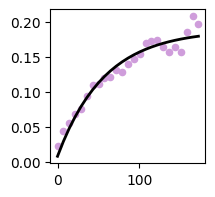

In [107]:
from interpmodules import helpers
from scipy.optimize import curve_fit

model = helpers.exponential
u=h
ev=expvgm[min_mae_ridx]
nparams = 3
nh=25
bounds = ([0.00001]*nparams, [np.nanmax(u), np.nanmax(ev), np.nanmax(ev)/nh])

cof, cov = curve_fit(model, u, ev, method = 'trf', p0=bounds[1], bounds = bounds, maxfev=1000)
v_pred = model(h, *cof)


plt.figure(figsize = (2,2))
plt.plot(h, v_pred, c="k", linewidth = 2, alpha = 1)

plt.scatter(h, expvgm[min_mae_ridx], s=20, c=cpal['structural'])

plt.savefig(projdir + '/figs/main/neuromaps_best_emp_variogram_fit.svg')

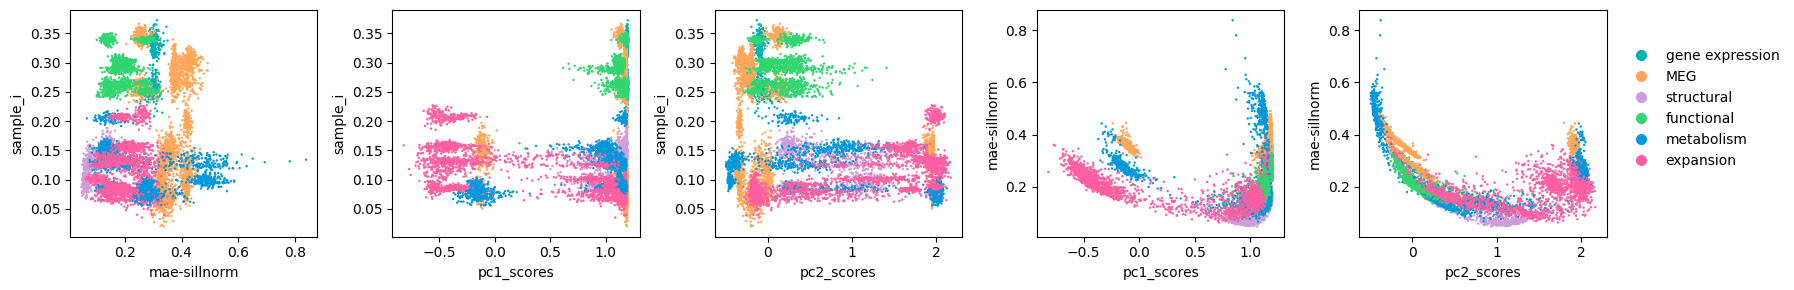

In [211]:
# add regression lines here

fig, axs = plt.subplots(1,5, figsize = (18,3))

for i, measure in enumerate(['mae-sillnorm', 'pc1_scores', 'pc2_scores']):
    
    sns.scatterplot( samp_stats, x=measure, y='sample_i', \
                    hue = 'category', palette=cpal, \
                     s=3, edgecolor = 'none',\
                     legend=False, ax=axs[i], rasterized=True)
    
sns.scatterplot( samp_stats, x='pc1_scores', y='mae-sillnorm', \
                    hue = 'category', palette=cpal, \
                     s=3, edgecolor = 'none',\
                     legend=False, ax=axs[3], rasterized=True)

sns.scatterplot( samp_stats, x='pc2_scores', y='mae-sillnorm', \
                    hue = 'category', palette=cpal, \
                     s=3, edgecolor = 'none',\
                     legend=False, ax=axs[4], rasterized=True)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="k", linewidth =0, \
           markeredgecolor = 'none',\
           markerfacecolor=to_rgba(ccolours[ci]), markersize=8, \
           label=cat)
    for ci, cat in enumerate(corder)
]

plt.legend(handles=legend_elements, \
           loc='lower right', \
           frameon=False, \
           ncol = 1,\
            bbox_to_anchor=(1.75, 0.25),  # outside right
            borderaxespad=0.5)


plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_variograms_dsk33_samples_pc1-mae.svg')

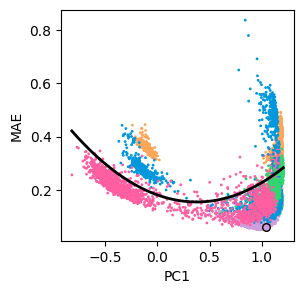

In [100]:
plt.figure(figsize = (3,3))

removed_nan = samp_stats.dropna()
df = removed_nan
x = df["pc1_scores"].to_numpy().astype(float)
y = df["mae-sillnorm"].to_numpy().astype(float)

coeffs = np.polyfit(x, y, 2)

# Create smooth curve
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = np.polyval(coeffs, x_fit)

plt.scatter(x=samp_stats['pc1_scores'], y=samp_stats['mae-sillnorm'], c=colour_categories, s= 1, rasterized = True,)
plt.scatter(x=samp_stats['pc1_scores'][min_mae_ridx], y=samp_stats['mae-sillnorm'][min_mae_ridx], \
            c=colour_categories[min_mae_ridx], edgecolor = 'k', s= 30, zorder=10)

plt.plot(x_fit, y_fit, color = 'k', linewidth = 2, zorder = 10)
plt.xlabel("PC1")
plt.ylabel("MAE")
plt.savefig(projdir + '/figs/main/neuromaps_variograms_dsk33_samples_pc1-mae_sill-normalized.svg')

In [218]:
coeffs

array([ 0.18701453, -0.14090649,  0.18095635])

In [219]:
y_pred = np.polyval(coeffs, x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - ss_res / ss_tot
print("R²:", r2)

n = len(x)
p = 2  # number of predictors (not counting intercept)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adj_r2)


rmse = np.sqrt(np.mean((y - y_pred)**2))
print("RMSE:", rmse)


R²: 0.0932687448288424
Adjusted R²: 0.09307962578511075
RMSE: 0.10395844936504191


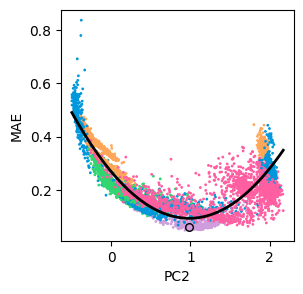

In [101]:
plt.figure(figsize = (3,3))

removed_nan = samp_stats.dropna()
df = removed_nan
x = df["pc2_scores"].to_numpy().astype(float)
y = df["mae-sillnorm"].to_numpy().astype(float)

coeffs = np.polyfit(x, y, 2)

# Create smooth curve
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = np.polyval(coeffs, x_fit)

plt.scatter(x=samp_stats['pc2_scores'], y=samp_stats['mae-sillnorm'], c=colour_categories, s= 1, rasterized = True,)
plt.scatter(x=samp_stats['pc2_scores'][min_mae_ridx], y=samp_stats['mae-sillnorm'][min_mae_ridx], \
            c=colour_categories[min_mae_ridx], edgecolor = 'k', s= 30, zorder=10)


plt.plot(x_fit, y_fit, color = 'k', linewidth = 2, zorder = 10)
plt.xlabel("PC2")
plt.ylabel("MAE")
plt.savefig(projdir + '/figs/main/neuromaps_variograms_dsk33_samples_pc2-mae_sill-normalized.svg')

In [88]:
coeffs

array([ 0.18209624, -0.35800559,  0.26894517])

In [89]:
y_pred = np.polyval(coeffs, x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - ss_res / ss_tot
print("R²:", r2)

n = len(x)
p = 2  # number of predictors (not counting intercept)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adj_r2)

rmse = np.sqrt(np.mean((y - y_pred)**2))
print("RMSE:", rmse)

R²: 0.7923943548444919
Adjusted R²: 0.7923510540529275
RMSE: 0.04974392835115156


## Collect stats for the OLS

In [ ]:
concat_rank_scores = pd.DataFrame()
strategy = 'dsk33'
geometry = 'reduced-midthickness'
for mi, maptag in enumerate(maptags):
    for pi, percentage in enumerate(test_percentages):
    
        tags, results = joblib.load( projdir + \
                               f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')
        
        #perf_scores = results['performance'][0]
        for i in range(niters):
            rank_scores = results[4][i][1]
            concat_rank_scores[maptag + "-" + str(percentage) + "-" + str(i) ] = rank_scores
#plt.savefig(projdir + "/figs/main/grf_random_samples_mean_rank_scores_heatmap.svg")

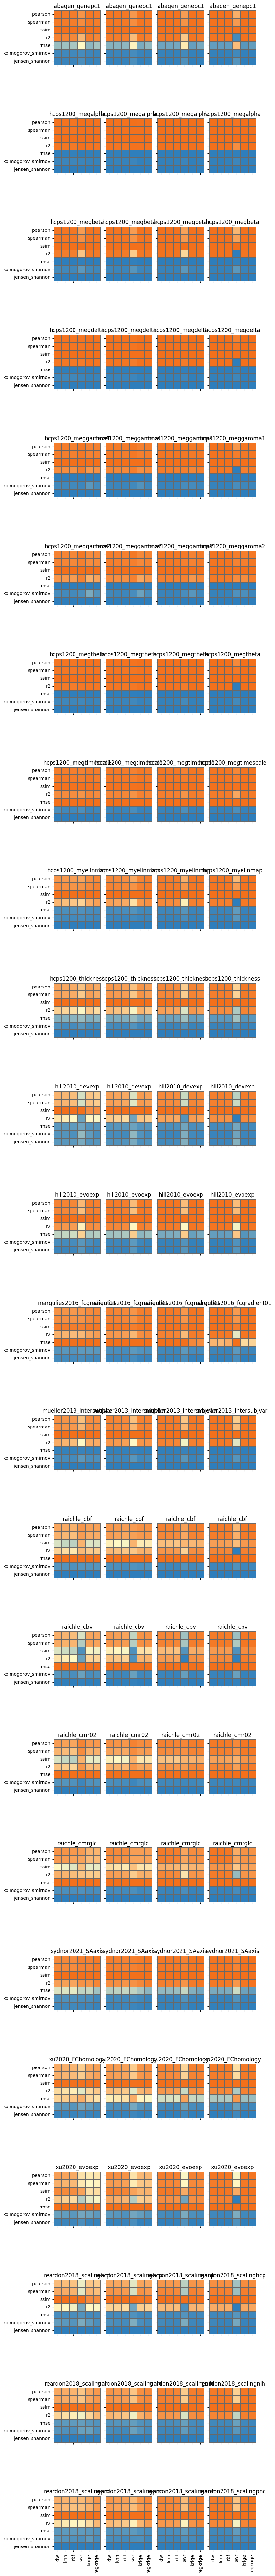

In [54]:
concat_rank_scores = pd.DataFrame()
strategy = 'dsk33'
geometry = 'reduced-midthickness'

#for mi, maptag in enumerate(maptags):

fig, axs = plt.subplots(len(maptags),4, figsize = (8, 80), sharex=True, sharey=True)

for mi, maptag in enumerate(maptags):
    
    for pi, percentage in enumerate(test_percentages):
        
        tags, results = joblib.load( projdir + \
                               f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')
        
        perf_scores = None
        
        for i in range(niters):
            #rank_scores = results[4][i][1]

            
            
            if i ==0:
                perf_scores = results[4][i][0].loc[metrics_to_consider[:-1]].fillna(0)
            else:
                perf_scores += results[4][i][0].loc[metrics_to_consider[:-1]].fillna(0)
        perf_scores= perf_scores / 100
    
        sns.heatmap( perf_scores, square=True, cmap = gnrd, vmin=0, \
                     vmax=1, linewidth = 1, linecolor = 'dimgray', ax=axs[mi, pi], cbar=False)
            #concat_rank_scores[maptag + "-" + str(percentage) + "-" + str(i) ] = rank_scores
        #plt.savefig(projdir + "/figs/main/grf_random_samples_mean_rank_scores_heatmap.svg")
        axs[mi, pi].set_title(maptag)
plt.tight_layout()
plt.savefig(projdir + '/figs/main/supplements_neuromaps_dsk33_samples_mean_performance_metrics.svg')

In [229]:
concat_rank_scores[['maptag', 'percentage', 'iteration']] = (
    concat_rank_scores.index
      .to_series()
      .str.split('-', expand=True)
)

In [230]:
concat_rank_scores.head()

,krige,idw,regkrige,knn,rbf,swr,maptag,percentage,iteration
abagen_genepc1-5-0,0.97619,0.857143,0.619048,0.547619,0.333333,0.166667,abagen_genepc1,5,0
abagen_genepc1-5-1,1.00000,0.833333,0.642857,0.523810,0.309524,0.190476,abagen_genepc1,5,1
abagen_genepc1-5-2,0.97619,0.738095,0.595238,0.595238,0.428571,0.166667,abagen_genepc1,5,2
abagen_genepc1-5-3,1.00000,0.809524,0.404762,0.642857,0.476190,0.166667,abagen_genepc1,5,3
abagen_genepc1-5-4,0.97619,0.761905,0.714286,0.500000,0.380952,0.166667,abagen_genepc1,5,4


In [231]:
concat_rank_scores.index = np.arange(len(concat_rank_scores))

In [232]:
concat_rank_scores['mae-sillnorm'] = variogram_gof_plotdata['mae']
concat_rank_scores['percentage'] = variogram_gof_plotdata['percentage']

In [233]:
len(concat_rank_scores)

9600

In [234]:
concat_rank_scores['sample_i'] = sample_global_i_s.flatten()

In [235]:
concat_rank_scores

,krige,idw,regkrige,knn,rbf,swr,maptag,percentage,iteration,mae-sillnorm,sample_i
0,0.976190,0.857143,0.619048,0.547619,0.333333,0.166667,abagen_genepc1,5,0,0.282620,0.232488
1,1.000000,0.833333,0.642857,0.523810,0.309524,0.190476,abagen_genepc1,5,1,0.300734,0.240406
2,0.976190,0.738095,0.595238,0.595238,0.428571,0.166667,abagen_genepc1,5,2,0.332414,0.214328
3,1.000000,0.809524,0.404762,0.642857,0.476190,0.166667,abagen_genepc1,5,3,0.282072,0.245816
4,0.976190,0.761905,0.714286,0.500000,0.380952,0.166667,abagen_genepc1,5,4,0.287077,0.246997
...,...,...,...,...,...,...,...,...,...,...,...
9595,0.714286,0.523810,1.000000,0.666667,0.428571,0.166667,reardon2018_scalingpnc,50,95,0.150103,0.088445
9596,0.833333,0.523810,1.000000,0.619048,0.357143,0.166667,reardon2018_scalingpnc,50,96,0.173672,0.090939
9597,0.357143,0.666667,1.000000,0.785714,0.523810,0.166667,reardon2018_scalingpnc,50,97,0.159248,0.088365
9598,0.785714,0.690476,0.952381,0.476190,0.428571,0.166667,reardon2018_scalingpnc,50,98,0.148277,0.090880


# Here I save the rank scores together with global metrics

In [236]:
joblib.dump(concat_rank_scores, projdir + '/results/stats/neuromaps_collected_per_sample_sill-normalized.pkl')

['/home/yzhou/gitrepo/interpolate//results/stats/neuromaps_collected_per_sample_sill-normalized.pkl']

In [239]:
df_long = concat_rank_scores.melt(
    id_vars=["maptag", "mae-sillnorm", "percentage", "sample_i"],
    value_vars=approaches,
    var_name="approach",
    value_name="rank"
)


In [240]:
df_long['map_i'] = np.zeros(len(df_long))

for row in range(len(df_long)):

    maptag = df_long.at[row, 'maptag']
    df_long.at[row, 'map_i'] = global_i_s.loc[maptag, 'i']

In [163]:
df_long['category'] = np.zeros(len(df_long))
for i in range(len(df_long)):
    df_long.at[i, 'category'] = global_i_s.loc[ df_long['maptag'][i] ]['category']

In [242]:
df_long

,maptag,mae-sillnorm,percentage,sample_i,approach,rank,map_i,category
0,abagen_genepc1,0.282620,5,0.232488,idw,0.857143,0.258006,gene expression
1,abagen_genepc1,0.300734,5,0.240406,idw,0.833333,0.258006,gene expression
2,abagen_genepc1,0.332414,5,0.214328,idw,0.738095,0.258006,gene expression
3,abagen_genepc1,0.282072,5,0.245816,idw,0.809524,0.258006,gene expression
4,abagen_genepc1,0.287077,5,0.246997,idw,0.761905,0.258006,gene expression
...,...,...,...,...,...,...,...,...
57595,reardon2018_scalingpnc,0.150103,50,0.088445,regkrige,1.000000,0.090995,expansion
57596,reardon2018_scalingpnc,0.173672,50,0.090939,regkrige,1.000000,0.090995,expansion
57597,reardon2018_scalingpnc,0.159248,50,0.088365,regkrige,1.000000,0.090995,expansion
57598,reardon2018_scalingpnc,0.148277,50,0.090880,regkrige,0.952381,0.090995,expansion


In [243]:
joblib.dump(df_long, projdir + '/results/stats/neuromaps_collected_ols_in_sill-normalized.pkl')

['/home/yzhou/gitrepo/interpolate//results/stats/neuromaps_collected_ols_in_sill-normalized.pkl']

## Linear Regression

### MAE ~ Moran's I

In [3]:
import joblib
concat_rank_scores = joblib.load(projdir + '/results/stats/neuromaps_collected_per_sample_sill-normalized.pkl')

In [4]:
in_data_chars = concat_rank_scores[['maptag', 'percentage', 'iteration','mae-sillnorm','sample_i']]

In [5]:
in_data_chars = in_data_chars.T.drop_duplicates().T

In [6]:
in_data_chars['mae'] = in_data_chars['mae-sillnorm']

In [8]:
import pandas as pd
in_data_chars['mae'] = pd.to_numeric(in_data_chars['mae'])
in_data_chars['sample_i'] = pd.to_numeric(in_data_chars['sample_i'])

In [9]:
import statsmodels.formula.api as smf
df = in_data_chars
df["iteration"] = df["iteration"].astype("category")
df["percentage"] = df["percentage"].astype("category")
df["maptag"] = df["maptag"].astype("category")

model = smf.ols(
    "mae ~ sample_i * ( C(maptag) + C(percentage) )",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mae   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.933
Method:                 Least Squares   F-statistic:                     7718.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:26:22   Log-Likelihood:                 20598.
No. Observations:                9592   AIC:                        -4.109e+04
Df Residuals:                    9538   BIC:                        -4.070e+04
Df Model:                          53                                         
Covariance Type:                  HC3                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [11]:
model.pvalues

Intercept                                           1.237288e-214
C(maptag)[T.hcps1200_megalpha]                       4.570975e-36
C(maptag)[T.hcps1200_megbeta]                        3.995956e-37
C(maptag)[T.hcps1200_megdelta]                       6.380631e-14
C(maptag)[T.hcps1200_meggamma1]                      1.098882e-97
C(maptag)[T.hcps1200_meggamma2]                      1.478123e-24
C(maptag)[T.hcps1200_megtheta]                       8.340451e-01
C(maptag)[T.hcps1200_megtimescale]                   1.010675e-11
C(maptag)[T.hcps1200_myelinmap]                      1.395071e-29
C(maptag)[T.hcps1200_thickness]                     7.236133e-145
C(maptag)[T.hill2010_devexp]                         5.072668e-01
C(maptag)[T.hill2010_evoexp]                         3.593247e-01
C(maptag)[T.margulies2016_fcgradient01]              1.409561e-33
C(maptag)[T.mueller2013_intersubjvar]                2.265990e-03
C(maptag)[T.raichle_cbf]                             3.984934e-47
C(maptag)[

In [16]:
np.where(model.pvalues == model.pvalues['sample_i'])

(array([27]),)

In [19]:
from statsmodels.stats.multitest import multipletests

multipletests( model.pvalues, alpha=0.05, method='bonferroni', maxiter=1, is_sorted=False, returnsorted=False)[1][27]

np.float64(1.2709633140607145e-08)

In [260]:
for i in range(len(in_data_chars)):
    in_data_chars.at[i, 'category'] = global_i_s.loc[ in_data_chars['maptag'][i] ]['category']

<Figure size 400x200 with 0 Axes>

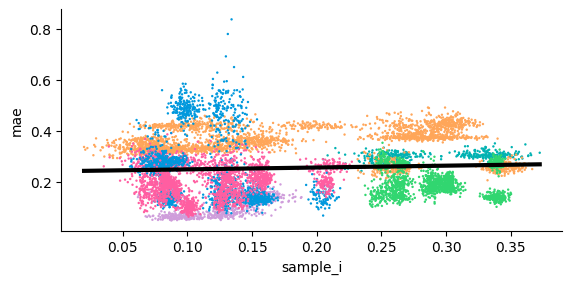

In [261]:
import seaborn as sns
plt.figure(figsize = (4,2))
g = sns.lmplot(
    data=df,
    x="sample_i",
    y="mae",
    col_wrap=None,
    ci=None,
    scatter=False,
    line_kws={"linewidth": 3, "color": 'k'},
    legend = False,
    height = 3, aspect=2
)



sns.scatterplot(in_data_chars, x='sample_i', y='mae', hue = 'category', s=3, palette=cpal, legend=False, edgecolor = 'none', rasterized=True)
plt.savefig(projdir + "/figs/main/neuromaps_morans_i_mae_scatterplot_sill-normalized.svg")

### rank ~ MAE + Moran's I

In [21]:
df_long = joblib.load(projdir + '/results/stats/neuromaps_collected_ols_in_sill-normalized.pkl')

In [22]:
import statsmodels.formula.api as smf
df = df_long
df['mae'] = df['mae-sillnorm']
df["approach"] = df["approach"].astype("category")
df["percentage"] = df["percentage"].astype("category")
df["maptag"] = df["maptag"].astype("category")

model = smf.ols(
    "rank ~ (mae + sample_i) *( C(approach) + C(percentage) + C(maptag) )",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     1363.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:42:51   Log-Likelihood:                 20475.
No. Observations:               57303   AIC:                        -4.076e+04
Df Residuals:                   57207   BIC:                        -3.990e+04
Df Model:                          95                                         
Covariance Type:                  HC3                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [25]:
np.where( model.pvalues == model.pvalues['mae'] )

(array([32]),)

In [26]:
from statsmodels.stats.multitest import multipletests

multipletests(model.pvalues, method = 'bonferroni')[1][32]

np.float64(1.0)

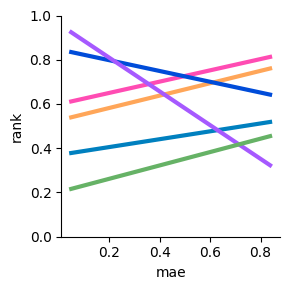

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df_long,
    x='mae',
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter=False,
    #scatter_kws={"s": 20, "alpha": .01, "edgecolor": "none", "rasterized":True},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)
plt.ylim([0,1])

plt.tight_layout()

plt.savefig(projdir + '/figs/main/neuromaps_rank-mae_ols_slopes_sill-normalized.svg')


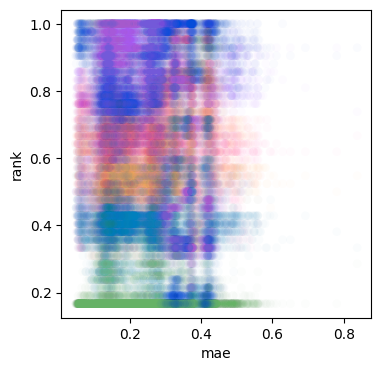

In [271]:
plt.figure(figsize = (4,4))
df_shorter = df.drop(columns = ['sample_i'])
df_shorter = df_shorter.drop_duplicates(subset=['mae', 'approach'])
sns.scatterplot(df_shorter, x= 'mae', y='rank', edgecolor = 'none', alpha = .02, s = 40, hue = 'approach', palette = apal, legend = False, rasterized=True)
plt.savefig(projdir + '/figs/main/neuromaps_rank-mae_scatter_sill-normalized.svg')

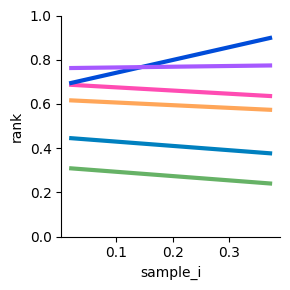

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df_long,
    x='sample_i',
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter=False,
    #scatter_kws={"s": 20, "alpha": .01, "edgecolor": "none", "rasterized": True},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)
plt.ylim([0,1])

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_rank-morans_i_ols_slopes_sill-normalized.svg')


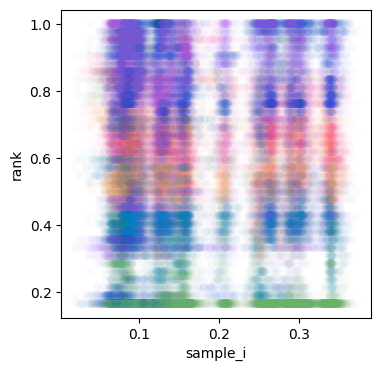

In [273]:
plt.figure(figsize = (4,4))
sns.scatterplot(df_long, x= 'sample_i', y='rank', edgecolor = 'none', alpha = .02, s = 40, \
                hue = 'approach', palette = apal, legend = False, rasterized=True)
#plt.show()
plt.savefig(projdir + '/figs/main/neuromaps_rank-morans_i_scatter_sill-normalized.svg')

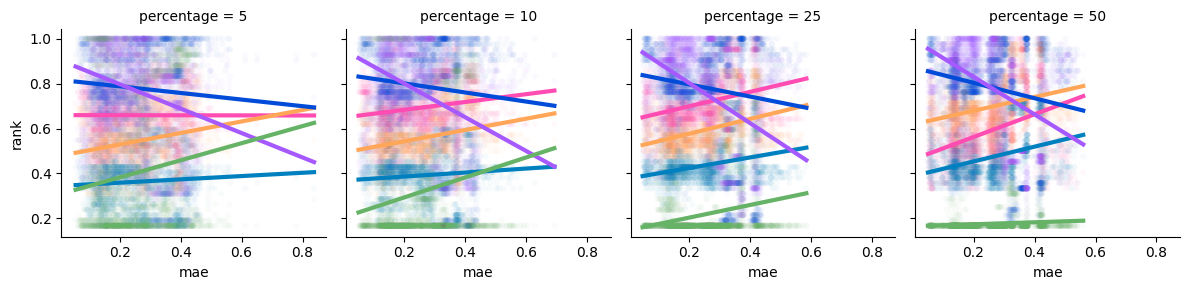

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df,
    x='mae',
    y="rank",
    hue="approach",
    col = "percentage",
    col_wrap=None,
    ci=None,
    scatter_kws={"s": 20, "alpha": .03, "edgecolor": "none", "rasterized":True},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

plt.tight_layout()
plt.savefig(projdir + "/figs/main/supplements_neuromaps_rank_mae_ols_by_percentage_sill-normalized.svg")

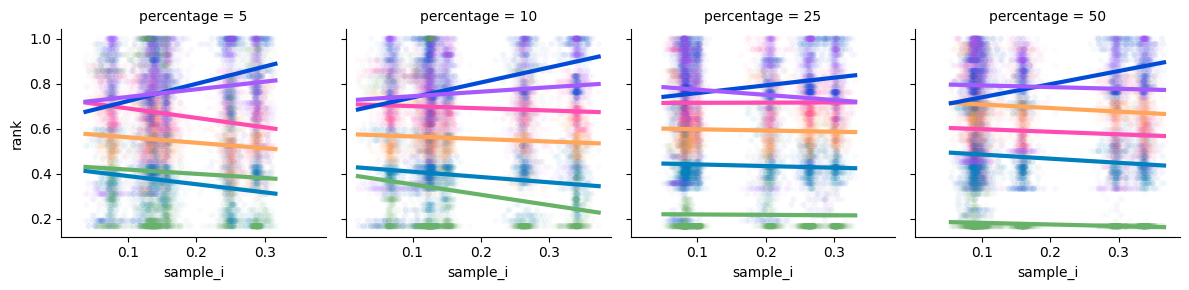

In [275]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df,
    x='sample_i',
    y="rank",
    hue="approach",
    col = "percentage",
    col_wrap=None,
    ci=None,
    scatter_kws={"s": 20, "alpha": .03, "edgecolor": "none", "rasterized":True},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

plt.tight_layout()

plt.savefig(projdir + "/figs/main/supplements_neuromaps_rank_moran_ols_by_percentage_sill-normalized.svg")

In [27]:
df_filtered = df_long[df_long["approach"].isin(["krige", "regkrige"])]


In [28]:
df_filtered["approach"] = df_filtered["approach"].astype("category").cat.remove_unused_categories()

/tmp/ipykernel_2823930/3692581379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["approach"] = df_filtered["approach"].astype("category").cat.remove_unused_categories()


In [112]:
import statsmodels.formula.api as smf
df = df_filtered

df["approach"] = df["approach"].astype("category")
df["percentage"] = df["percentage"].astype("category")
df["maptag"] = df["maptag"].astype("category")

model = smf.ols(
    "rank ~ ( mae + sample_i ) * (C(approach) + C(percentage) + C(maptag))",
    data=df
).fit(cov_type="HC3")

print(model.summary())

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.572
Model:                            OLS   Adj. R-square

In [29]:
np.where( model.pvalues.index == 'mae:C(approach)[T.regkrige]' )

(array([36]),)

In [33]:
from statsmodels.stats.multitest import multipletests

multipletests(model.pvalues, method = 'bonferroni')[1][1]

np.float64(9.449041950294557e-40)

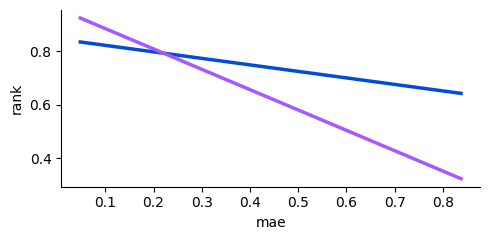

In [35]:
import seaborn as sns

g=sns.lmplot(
    data=df,
    x="mae",
    y="rank",
    hue="approach",        # krige vs regkrige
    ci=None,
    scatter=False,
    #scatter_kws={"s": 20, "alpha": 0.02, "edgecolor": "none", "rasterized":True},
    palette=apal,
    legend=False,
    line_kws={"linewidth": 2.5},
    aspect = 2, height = 2.5
)

#plt.savefig(projdir + "/figs/main/supplements_neuromaps_mae_rank_ols_skrk_sill-normalized.svg")
plt.savefig(projdir + "/figs/main/supplements_neuromaps_mae_rank_ols_skrk_slopes_sill-normalized.svg")

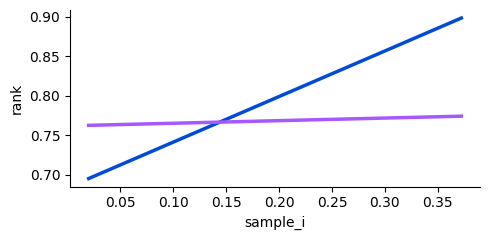

In [37]:
import seaborn as sns

g=sns.lmplot(
    data=df,
    x="sample_i",
    y="rank",
    hue="approach",        # krige vs regkrige
    ci=None,
    scatter=False,
    #scatter_kws={"s": 20, "alpha": 0.02, "edgecolor": "none", "rasterized":True},
    palette=apal,
    legend=False,
    line_kws={"linewidth": 2.5},
    aspect = 2, height = 2.5
)

#plt.savefig(projdir + "/figs/main/supplements_neuromaps_moran_rank_ols_skrk_sill-normalized.svg")
plt.savefig(projdir + "/figs/main/supplements_neuromaps_moran_i_rank_ols_skrk_slopes_sill-normalized.svg")

## Heatmap

In [283]:
df_wide = concat_rank_scores.groupby("maptag").mean(approaches)

In [284]:
rorder = df_wide.mean().sort_values(ascending=False).index

In [285]:
rorder

Index(['percentage', 'krige', 'regkrige', 'idw', 'knn', 'rbf', 'swr',
       'mae-sillnorm', 'sample_i'],
      dtype='object')

In [289]:
df_wide = df_wide[rorder[1:-2]]

In [290]:
df_wide = df_wide.reindex(global_i_s.index)

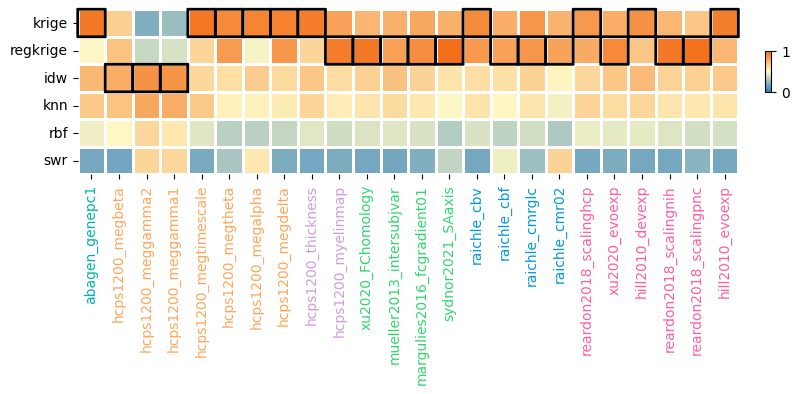

In [291]:
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize = (12,4))

data = df_wide.T

sns.heatmap( data, square = True, vmin = 0, vmax = 1, \
             linewidth = 2, linecolor = 'w',cmap = gnrd, \
             cbar = False, ax=ax)


for maptag in data.columns:
    col_label = maptag
    row_label = data[maptag].sort_values(ascending = False).index[0]

    i = data.index.get_loc(row_label)
    j = data.columns.get_loc(col_label)
    
    #ax.add_patch(
    #    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="dimgray", linewidth=2)
    #)
    
    ax.add_patch(
        FancyBboxPatch(
            (j, i), 1, 1,
            boxstyle="round,pad=0.0001",
            linewidth=2,
            edgecolor="k",
            facecolor="none", clip_on=False
        ))
    
for label in ax.get_xticklabels():

    cat_assign = global_i_s.loc[ label.get_text() ]['category']
    label.set_color(ccolours[corder.index(cat_assign)])


axins = inset_axes(
    ax,
    width="2%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower right",
    bbox_to_anchor=(0.55,0.5, 0.5, 0.5),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

fig.subplots_adjust(right=1.0, bottom = 0.2)

plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_dsk33_surf_maps_even_ranks.svg')

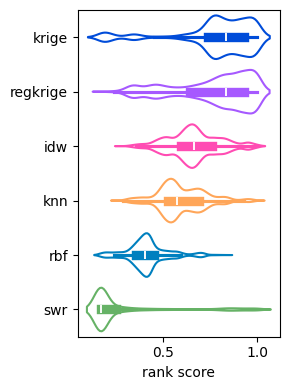

In [293]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (3,4), sharex=True)

sns.violinplot(concat_rank_scores[approaches], order = rorder[1:7], orient = 'h', inner = 'box', palette=apal,\
               fill=False, ax=ax)
ax.set_xlabel("rank score")
#sns.boxplot(concat_everything.T, order = methods_order, orient = 'h', fill=False, color = 'k', ax=axs[1], fliersize = 3)
#axs[1].set_xlabel("rank score")
# Increase median line width

plt.tight_layout()
#plt.savefig(projdir + '/figs/main/neuromaps_dsk33_surf_maps_even_ranks_violin.svg')

In [19]:
concat_rank_scores = concat_rank_scores.drop(columns = ["sample_i", "mae"])